In [20]:
import os
import sys
import pickle
import string
import string
import glob
import cv2

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

from sklearn.cluster import AgglomerativeClustering
from matplotlib.animation import FuncAnimation, MovieWriter
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
from itertools import product
from matplotlib import ticker

sys.path.append('..')
import massPy as mp
from utils import *
from plot_utils import *
from AnalyseDefects import AnalyseDefects
plt.style.use('sg_article')
plt.rcParams.update({"text.usetex": True,})


In [2]:

def extract_clp_results_single(clustering_dict, act_dir_list, save_path = None):
    """
    Analyse the defects for all the input folders
    """

    Nframes = clustering_dict['Nframes']
  
    # create arrays to store the clustering data
    cluster_arr = np.nan * np.zeros([Nframes, clustering_dict['Nwindows'], 3, clustering_dict['Nact'],])
    nn_arr = np.nan * np.zeros([Nframes, 2, clustering_dict['Nact']])

    for i, act_dir in enumerate(act_dir_list):
        print(i, act_dir)
        cl_res = np.load(os.path.join(act_dir, 'cl_arr.npy'))
        nn_res = np.load(os.path.join(act_dir, 'nn_arr.npy'))
        ff_idx = min(Nframes, cl_res.shape[0])
        cluster_arr[-ff_idx:, :cl_res.shape[1], :, i] = cl_res[-ff_idx:]
        nn_arr[-ff_idx:, :, i] = nn_res[-ff_idx:]

    if save_path is not None:
        if not os.path.isdir(save_path):
            os.makedirs(save_path)
        np.save(os.path.join(save_path, f'clp_arr.npy'), cluster_arr)
        np.save(os.path.join(save_path, f'nn_arr.npy'), nn_arr)
    return cluster_arr

def extract_op_results(Nframes, act_dir_list, LX, calc_sem = False, save_path = None):
    """
    Analyse the defects for all the input folders
    """

    order_param_arr = np.nan * np.zeros([Nframes, 4, len(act_dir_list)])
    normalizer = np.sqrt(LX ** 2) if calc_sem else 1

    for i, act_dir in enumerate(act_dir_list):
        print(i, act_dir)

        op_res = np.load(os.path.join(act_dir, 'order_param_arr.npy'))
        ff_idx = min(Nframes, op_res.shape[0])

        order_param_arr[-ff_idx:, :, i] = op_res[-ff_idx:]
        order_param_arr[-ff_idx:, 1, i] /= normalizer
        order_param_arr[-ff_idx:, 3, i] /= normalizer

    if save_path is not None:
        if not os.path.isdir(save_path):
            os.makedirs(save_path)
        np.save(os.path.join(save_path, f'order_param_arr.npy'), order_param_arr)
    return order_param_arr

def extract_dc_results(Nframes, act_dir_list, save_path = None):
    """
    Analyse the defects for all the input folders
    """

    for i, act_dir in enumerate(act_dir_list):
        print(i, act_dir)

        if i == 0:
            rvals = np.load(os.path.join(act_dir, 'rdf_rad_arr.npy'))
            rdf_arr = np.nan * np.zeros([Nframes, len(rvals), len(act_dir_list)])

        rdf = np.load(os.path.join(act_dir, 'rdf_arr.npy'))
        ff_idx = min(Nframes, rdf.shape[0])

        rdf_arr[-ff_idx:, :, i] = rdf[-ff_idx:]

    if save_path is not None:
        if not os.path.isdir(save_path):
            os.makedirs(save_path)
        np.save(os.path.join(save_path, f'rvals.npy'), rvals)
        np.save(os.path.join(save_path, f'rdf_arr.npy'), rdf_arr)
    return rdf_arr, rvals

def get_defect_arr_from_frame(defect_dict, return_charge = False):
    """
    Convert dictionary of defects to array of defect positions
    Parameters:
    -----------
    defect_dict : dict
        Dictionary of defects positions and charges
    return_charge : bool
        If True, return defect charges as well

    Returns:
    --------
    defect_positions : np.ndarray
        Array of defect positions
    defect_charges : np.ndarray
    """

    Ndefects = len(defect_dict)
    if Ndefects == 0:
        return None
    
    defect_positions = np.empty([Ndefects, 3 if return_charge else 2])

    for i, defect in enumerate(defect_dict):
        if return_charge:
            defect_positions[i,:] = *defect['pos'], defect['charge']
        else:
            defect_positions[i,:] = *defect['pos'],
    return defect_positions

def arg_func(arr, r_max_list, cutoff):
    if np.any(arr == cutoff):
        return r_max_list[np.argwhere(arr == cutoff)[0][0]]
    else:
        return -1
    
def arg_func_idx(arr, cutoff):
    if np.any(arr == cutoff):
        return np.argwhere(arr == cutoff)[0][0]
    else:
        return -1

def arg_func2(arr, cutoff):
    if np.any(arr == cutoff):
        return arr[np.argwhere(arr == cutoff)[0][0]]
    else:
        return -1
    
def get_defect_density(defect_list, area, return_charges=False, save_path = None,):
        """
        Get defect density for each frame in archive
        parameters:
            defect_list: list of lists of dictionaries holding defect charge and position for each frame 
            area: Area of system
            return_charges: if True, return list of densities of positive and negative defects
        returns:
            dens_defects: array of defect densities (Nframes, 3) if return_charges is True else (Nframes, 2)
        """

        if return_charges:
            # Initialize list of defect densities
            dens_pos_defects = []
            dens_neg_defects = []
            for defects in defect_list:
                # Get no. of defects
                nposdef = len([d for d in defects if d['charge'] == 0.5])
                nnegdef = len([d for d in defects if d['charge'] == -0.5])

                dens_pos_defects.append(nposdef / area)
                dens_neg_defects.append(nnegdef / area)

            if save_path is not None:
                np.savetxt(save_path + '_pos', dens_pos_defects)
                np.savetxt(save_path + '_neg', dens_neg_defects)
            return dens_pos_defects, dens_neg_defects
        else:
            dens_defects = []
            for defects in defect_list:
                # Get no. of defects
                ndef = len(defects)
                dens_defects.append(ndef / area)
            if save_path is not None:
                np.savetxt(save_path, dens_defects)
            return dens_defects

def find_conv_time(def_arr, act_list, out_path, fig_path, ninfo, LX, mode='fwd', plot_density = False, \
                   stationarity_dict = dict(interval_len = 20, Njump = 20, Nconverged = -100, max_sigma_dist = 1)):

    Nframes, Nact = def_arr.shape
    conv_list = np.zeros(Nact)

    ncols=3
    nrows = np.ceil(Nact / ncols).astype(int)
    fig, ax = plt.subplots(nrows=nrows,ncols=ncols, figsize=(12, 3*nrows))
    ax = ax.flatten()


    for i, act in enumerate(act_list):

            normalizer = LX ** 2 if plot_density else 1
            vals = def_arr[:, i] / normalizer

            av = np.mean(vals)
        

            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                x = est_stationarity(vals, **stationarity_dict)[0]

            conv_list[i] = x
            ax[i].plot(np.arange(0, Nframes * ninfo, ninfo), vals, '.',
                        alpha = .5, markersize=9, label = rf'$dQ$ = {act}')
        
            if x > 0:
                ax[i].axvline(x * ninfo, color='black', linestyle='--', alpha=0.5)
            ax[i].set_ylim([0, 2 * av])
            ax[i].legend()  
            ax[i].grid(True)


    fig.supxlabel('Time')
    fig.supylabel('Number of defects')


    np.save(os.path.join(out_path, 'conv_list.npy'), conv_list)
    fig.savefig(os.path.join(fig_path, f'num_defects_{mode}{LX}.png'))

    # close figure
    plt.close(fig)
    return

def calc_lmax_lperc(clp_arr, rmax_list, act_list, conv_list, save_path, uncertainty_multiplier = 1, nmin_frames = 20):
    

    lmax_av = np.nan * np.zeros((len(act_list), 2))
    lperc_av = np.nan * np.zeros((len(act_list), 2))

    arg_func1d = lambda arr: arg_func(arr, rmax_list, cutoff = 1)
    lmax_arr = np.apply_along_axis(arg_func1d, axis=1, arr=clp_arr[:, :, -1, :,])
    lperc_arr = np.apply_along_axis(arg_func1d, axis=1, arr=clp_arr[:, :, 0, :,])

    for i, _ in enumerate(act_list):
        ff_idx = int(conv_list[i])

        mask = (lmax_arr[ff_idx:, i,] > 0)
        nsamples = mask.sum()
        if nsamples > nmin_frames:
            arr_res = lmax_arr[ff_idx:, i,][mask]
            lmax_av[i,0] = np.nanmean(arr_res)
            lmax_av[i,1] = np.nanstd(arr_res, ddof = 1,) / np.sqrt(nsamples / uncertainty_multiplier)


        mask_perc = (lperc_arr[ff_idx:, i,] > 0)
        nsamples_perc = mask_perc.sum()
        if nsamples_perc  > nmin_frames:
            arr_res_perc = lperc_arr[ff_idx:, i,][mask_perc]
            lperc_av[i,0] = np.nanmean(arr_res_perc)
            lperc_av[i,1] = np.nanstd(arr_res_perc, ddof = 1,) / np.sqrt(nsamples_perc / uncertainty_multiplier)

    np.save(os.path.join(save_path, 'lmax_arr.npy'), lmax_arr)
    np.save(os.path.join(save_path, 'lperc_arr.npy'), lperc_arr)
    np.save(os.path.join(save_path, 'lmax_av.npy'), lmax_av)
    np.save(os.path.join(save_path, 'lperc_av.npy'), lperc_av)
    return

def calc_nn_avg(nn_arr, def_arr, act_list, conv_list, LX, \
                uncertainty_multiplier = 1, weighted=False, \
                normalize = True, nmin_samples = 20, 
                save_path = None):
    
    nn_av = np.nan * np.zeros((len(act_list), 2))

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for j in range(len(act_list)):
            ff_idx = int(conv_list[j])
            normalizer = LX / np.sqrt(def_arr[ff_idx:,j]) if normalize else 1
            
            if (nn_arr[:,0,j] > 0).sum() >=  nmin_samples:
                if weighted:
                    nn_av[j] = calc_weighted_mean_vec(nn_arr[ff_idx:,0,j] / normalizer, 
                                                                nn_arr[ff_idx:,1,j] / normalizer, replace_null_uncertainties=True)[:2]
                    nn_av[j,1] *= np.sqrt(uncertainty_multiplier)
                else:
                    nn_av[j,0] = np.nanmean(nn_arr[ff_idx:,0,j] / normalizer)
                    nn_av[j,1] = np.nanstd(nn_arr[ff_idx:,0,j] / normalizer, ddof = 1,) \
                        / np.sqrt(nn_arr[ff_idx:,0,j].size / uncertainty_multiplier)           
    if save_path is not None:
        if not os.path.isdir(save_path):
            os.makedirs(save_path)
        np.save(os.path.join(save_path, 'nn_av.npy'), nn_av)
    return nn_av

def calc_dc_avg(rdf_arr, act_list, conv_list, \
                uncertainty_multiplier = 1, njump=5,
                save_path = None):
    

    
    rdf_arr_av = np.nan * np.zeros((len(act_list), 2, rdf_arr.shape[1]))
  
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for j in range(len(act_list)):
            ff_idx = int(conv_list[j] / njump)
            rdf_arr_res = rdf_arr[ff_idx:,:,j]
            #nan_mask = np.isnan(rdf_arr_res)
            #rdf_arr_res = rdf_arr_res[~nan_mask]

            rdf_arr_av[j,0,:] = np.nanmean(rdf_arr_res, axis=0)
            rdf_arr_av[j,1,:] = np.nanstd(rdf_arr_res, axis=0, ddof = 1,) \
                / np.sqrt(rdf_arr_res.size / uncertainty_multiplier)        
    if save_path is not None:
        if not os.path.isdir(save_path):
            os.makedirs(save_path)
        np.save(os.path.join(save_path, 'rdf_arr_av.npy'), rdf_arr_av)
    return rdf_arr_av

def calc_order_param_avg(order_param_arr, act_list, conv_list, \
                uncertainty_multiplier = 1, weighted=False, \
                save_path = None):
    
    order_param_av = np.nan * np.zeros((len(act_list), 4))

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for j in range(len(act_list)):
            ff_idx = int(conv_list[j])
   
            if weighted:
                order_param_av[j, :2] = calc_weighted_mean_vec(order_param_arr[ff_idx:,0,j], 
                                                            order_param_arr[ff_idx:,1,j] * np.sqrt(uncertainty_multiplier))[:2]
                order_param_av[j, 2:] = calc_weighted_mean_vec(order_param_arr[ff_idx:,2,j], 
                                                            order_param_arr[ff_idx:,3,j] * np.sqrt(uncertainty_multiplier))[:2]
                order_param_av[j,1] *= np.sqrt(uncertainty_multiplier)
                order_param_av[j,3] *= np.sqrt(uncertainty_multiplier)
            else:
                order_param_av[j,0] = np.nanmean(order_param_arr[ff_idx:,0,j])
                order_param_av[j,1] = np.nanstd(order_param_arr[ff_idx:,0,j], ddof = 1,) \
                    / np.sqrt(order_param_arr[ff_idx:,0,j].size / uncertainty_multiplier)           
                order_param_av[j,2] = np.nanmean(order_param_arr[ff_idx:,2,j])
                order_param_av[j,3] = np.nanstd(order_param_arr[ff_idx:,2,j], ddof = 1,) \
                    / np.sqrt(order_param_arr[ff_idx:,2,j].size / uncertainty_multiplier)           
    if save_path is not None:
        if not os.path.isdir(save_path):
            os.makedirs(save_path)
        np.save(os.path.join(save_path, 'order_param_av.npy'), order_param_av)
    return order_param_av
        
def plot_order_param(order_param_arr, act_list, Nframes, ninfo, \
                    act_idx_exclude_list = [], lambda_val=None, save_path=None, \
                    ylim = None, mode = 'wet', direction = 'fwd'):
    
    fig, ax = plt.subplots()

    direction = 'forward' if direction == 'fwd' else 'backward'

    for j in range(len(act_list)):
        if j in act_idx_exclude_list: continue

        xvals = np.arange(0, Nframes * ninfo, ninfo)
        ax.plot(xvals, order_param_arr[:,0,j], '.-', label  = f'{act_list[j]}', alpha = .5)
    ax.set_xlabel('Time step')
    ax.set_ylabel('Order parameter (S)')

    ax.legend(ncols=7, loc='upper right',fontsize=12)   
    ax.set_title(rf' $\lambda = ${lambda_val} ({direction})' if mode == 'wet' else rf'Dry ({direction})')
    if ylim is not None:
        ax.set_ylim(ylim)

    fig.tight_layout()  

    if save_path is not None:
        fig.savefig(save_path)
    return fig, ax

def plot_order_param_double(order_param_arr, act_list, idx_lower, Nframes, ninfo, \
                    act_idx_exclude_list = [], lambda_val=None, save_path=None, \
                    ylim_list = None, mode = 'wet', direction = 'fwd'):
    
    fig, ax = plt.subplots(ncols=2, figsize=(12, 6))
    for j in range(len(act_list)):
        if j in act_idx_exclude_list: continue
        ff_idx = 0
        ax[0 if j<idx_lower else 1].plot(order_param_arr[:,0,j], label  = f'{act_list[j]}')
    fig.supxlabel('Time step')
    fig.supylabel('Order parameter (S)')
    fig.suptitle(rf' $\lambda = ${lambda_val} ({direction})' if mode == 'wet' else rf'Dry ({direction})')
    fig.tight_layout()

    for i, axx in enumerate(ax):
        axx.set_ylim([-.05, .25]) if ylim_list is None else axx.set_ylim(ylim_list[i])
        axx.legend(ncol=4, loc='upper right', fontsize=12)

    if save_path is not None:
        fig.savefig(save_path)
    return fig, ax


In [36]:
LX = 256
mode = 'dryvl' 
calc_order_param_sem = False
save_figs = False
letter_subfigs = True

extract = False
extract_op, extract_dc = False, False
extract_def, find_conv = False, False
analyze= False

nmin_frames = 10 #if #mode == 'wet' else 5
uncertainty_multiplier = 20
njump_between_frames = 5
weighted = True

ext_fwd=False

if mode == 'wet':
    folder_name = 'diff_lambda_periodic'
    lambda_list = [0,]# 1] # [0.1, 0.5, 0.8]#1] #1]
    subdir_name = 'wet'
elif mode == 'dry':
    folder_name = 'dry_periodic_long'
    lambda_list = [1,]
    subdir_name = 'dry'
elif mode == 'dryvl':
    folder_name = 'dry_periodic_vl'
    lambda_list = [1,]
    subdir_name = 'dry'
elif mode == 'ac':
    folder_name = 'ac_periodic'
    lambda_list = [0,1]
    subdir_name = 'wet'

out_path_all = f'C:\\Users\\Simon Andersen\\Projects\\Projects\\Thesis\\NematicAnalysis\\data\\passive\\{folder_name}\{mode}\\na{LX}'
defect_position_dir = f'C:\\Users\\Simon Andersen\\Projects\\Projects\\Thesis\\NematicAnalysis\\data\\passive'
figpath_article='C:\\Users\\Simon Andersen\\Documents\\Uni\\PhD\\Research\\Defect Unbinding\\Figs'

for lambda_val in lambda_list:

    base_path_fwd = f'Z:\\defect_unbinding\\{folder_name}\\{subdir_name}\\na{LX}\\{lambda_val}\\fwd'
    base_path_bck = f'Z:\\defect_unbinding\\{folder_name}\\{subdir_name}\\na{LX}\\{lambda_val}\\bck'

    out_path_main = os.path.join(out_path_all, f'{lambda_val}') #if mode == 'wet' else out_path_all
    out_path_fwd = os.path.join(out_path_main, 'fwd')
    out_path_bck = os.path.join(out_path_main, 'bck')
    fig_path = os.path.join(out_path_main, 'figs')

    if extract or extract_def or extract_op or extract_dc:
        if not os.path.isdir(fig_path):
            os.makedirs(fig_path)
        if not os.path.isdir(out_path_main):
            os.makedirs(out_path_main)
        if not os.path.isdir(out_path_fwd):
            os.makedirs(out_path_fwd)
        if not os.path.isdir(out_path_bck):
            os.makedirs(out_path_bck)

        print(f'Analyzing {mode} with lambda = {lambda_val}')
        t1 = time.perf_counter()    

        act_dirs_fwd = [os.path.join(base_path_fwd, x) for x in os.listdir(base_path_fwd)]
        act_dirs_bck = [os.path.join(base_path_bck, x) for x in os.listdir(base_path_bck)] 

        if extract_def:
            base_path_defects_fwd = f'Z:\\defect_unbinding\\{folder_name}\\{subdir_name}\\na{LX}\\{lambda_val}\\defect_positions\\fwd'
            base_path_defects_bck = f'Z:\\defect_unbinding\\{folder_name}\\{subdir_name}\\na{LX}\\{lambda_val}\\defect_positions\\bck'
            act_dirs_def_fwd = [os.path.join(base_path_defects_fwd, x) for x in os.listdir(base_path_defects_fwd)]
            act_dirs_def_bck = [os.path.join(base_path_defects_bck, x) for x in os.listdir(base_path_defects_bck)]

        act_fwd = [float(x.split('-')[-2]) for x in os.listdir(base_path_fwd)]
        act_bck = [float(x.split('-')[-2]) for x in os.listdir(base_path_bck)]

        # save activity list
        np.save(os.path.join(out_path_fwd, 'act_fwd.npy'), act_fwd)
        np.save(os.path.join(out_path_bck, 'act_bck.npy'), act_bck)
    else:
        act_fwd = np.load(os.path.join(out_path_fwd, 'act_fwd.npy'))
        act_bck = np.load(os.path.join(out_path_bck, 'act_bck.npy'))

    act_exclude_fwd = []
    act_exclude_bck = []

    Nact_fwd = len(act_fwd)
    Nact_bck = len(act_bck)
    Nact_list = [Nact_fwd, Nact_bck]

    rmax_list = np.arange(1, int(LX / np.sqrt(2))) 
    Nframes = 1000 #if mode=='wet' #else 50
    Nwindows = len(rmax_list)
    ninfo = 1000

    cluster_dict_fwd = dict(LX = LX, Nframes = Nframes, \
                        Nact = len(act_fwd), \
                        Nwindows = len(rmax_list), \
                        path = out_path_fwd, suffix = '_fwd')
    cluster_dict_bck = dict(LX = LX, Nframes = Nframes, \
                        Nact = len(act_bck), \
                        Nwindows = len(rmax_list), \
                        path = out_path_bck, suffix = '_bck')
    
    if extract_def:
            def_arr_fwd = np.zeros([Nframes, Nact_fwd])
            def_arr_bck = np.zeros([Nframes, Nact_bck])

            for i, (act_dir_list, arr) in enumerate(zip([act_dirs_def_fwd, act_dirs_def_bck], [def_arr_fwd, def_arr_bck])):
                print("Extracting defects for", 'fwd' if i == 0 else 'bck')
                for j, act_dir in enumerate(act_dir_list):
                    print(j)
                    path = os.path.join(act_dir, 'defect_positions.pkl')
                    with open(path, 'rb') as f:
                        defect_dict = pickle.load(f)
                    def_list_pos = get_defect_density(defect_dict, area = 1)
                    ff_idx = min(Nframes, len(def_list_pos))
                    arr[-ff_idx:, j] = def_list_pos[-ff_idx:]

            # save 
            np.save(os.path.join(out_path_fwd, 'def_arr.npy'), def_arr_fwd)
            np.save(os.path.join(out_path_bck, 'def_arr.npy'), def_arr_bck)
    if extract:
        clp_arr_fwd = extract_clp_results_single(cluster_dict_fwd, act_dirs_fwd, save_path=out_path_fwd)
        clp_arr_bck = extract_clp_results_single(cluster_dict_bck, act_dirs_bck, save_path=out_path_bck)
    else:
        clp_arr_fwd = np.load(os.path.join(out_path_fwd, 'clp_arr.npy'))
        clp_arr_bck = np.load(os.path.join(out_path_bck, 'clp_arr.npy'))
        def_arr_fwd = np.load(os.path.join(out_path_fwd, 'def_arr.npy'))
        def_arr_bck = np.load(os.path.join(out_path_bck, 'def_arr.npy'))
        nn_arr_fwd = np.load(os.path.join(out_path_fwd, 'nn_arr.npy'))
        nn_arr_bck = np.load(os.path.join(out_path_bck, 'nn_arr.npy'))
    if extract_op:
        order_param_arr_fwd = extract_op_results(Nframes, act_dirs_fwd, LX, calc_sem=calc_order_param_sem, save_path=out_path_fwd)
        order_param_arr_bck = extract_op_results(Nframes, act_dirs_bck, LX, calc_sem=calc_order_param_sem, save_path=out_path_bck)
    else:
        try:
            order_param_arr_fwd = np.load(os.path.join(out_path_fwd, 'order_param_arr.npy'))
            order_param_arr_bck = np.load(os.path.join(out_path_bck, 'order_param_arr.npy'))
        except:
            pass
    if extract_dc:
        rdf_arr_fwd, rvals_fwd = extract_dc_results(Nframes, act_dirs_fwd, save_path=out_path_fwd)
        rdf_arr_bck, rvals_bck = extract_dc_results(Nframes, act_dirs_bck, save_path=out_path_bck)
    else:
        try:
            rdf_arr_fwd = np.load(os.path.join(out_path_fwd, 'rdf_arr.npy'))
            rdf_arr_bck = np.load(os.path.join(out_path_bck, 'rdf_arr.npy'))
            rvals_fwd = np.load(os.path.join(out_path_fwd, 'rvals.npy'))
            rvals_bck = np.load(os.path.join(out_path_bck, 'rvals.npy'))
        except:
            pass
    if not find_conv:
        try:
            conv_list_fwd = np.load(os.path.join(out_path_fwd, 'conv_list.npy'))
            conv_list_bck = np.load(os.path.join(out_path_bck, 'conv_list.npy'))
        except:
            conv_list_bck = np.zeros(Nact_bck)
            conv_list_fwd = np.zeros(Nact_fwd)
    else:
        block_size = 20 #if mode=='wet' else 5
        Nconverged = 5*block_size
        find_conv_time(def_arr_fwd, act_fwd, out_path_fwd, fig_path, ninfo, LX, mode='fwd', plot_density = False, \
                stationarity_dict = dict(interval_len = block_size, Njump = block_size, Nconverged = Nconverged, max_sigma_dist = 1))
        find_conv_time(def_arr_bck, act_bck, out_path_bck, fig_path, ninfo, LX, mode='bck', plot_density = False, \
                stationarity_dict = dict(interval_len = block_size, Njump = block_size, Nconverged = Nconverged, max_sigma_dist = 1))
    if analyze:
        print(f'Analyzing {mode} lambda=', lambda_val) 
        
        
        calc_lmax_lperc(clp_arr_fwd, rmax_list, act_fwd, conv_list_fwd, out_path_fwd, \
                        uncertainty_multiplier = uncertainty_multiplier/5 if Nframes<100 else uncertainty_multiplier, \
                            nmin_frames = nmin_frames)
        calc_lmax_lperc(clp_arr_bck, rmax_list, act_bck, conv_list_bck, out_path_bck, \
                        uncertainty_multiplier = uncertainty_multiplier/5 if Nframes<100 else uncertainty_multiplier, \
                            nmin_frames = nmin_frames)
        calc_nn_avg(nn_arr_fwd, def_arr_fwd, act_fwd, conv_list_fwd, LX, \
                uncertainty_multiplier = uncertainty_multiplier, weighted=weighted, normalize = True, nmin_samples = nmin_frames, 
                save_path = out_path_fwd)
        calc_nn_avg(nn_arr_bck, def_arr_bck, act_bck, conv_list_bck, LX, \
                uncertainty_multiplier = uncertainty_multiplier, weighted=weighted, normalize = True, nmin_samples = nmin_frames, 
                save_path = out_path_bck)
        order_param_fwd_av = calc_order_param_avg(order_param_arr_fwd, act_fwd, conv_list_fwd, \
                uncertainty_multiplier = uncertainty_multiplier, weighted=True, save_path = out_path_fwd)
        order_param_bck_av = calc_order_param_avg(order_param_arr_bck, act_bck, conv_list_bck, \
                uncertainty_multiplier = uncertainty_multiplier, weighted=True, save_path = out_path_bck)
        try:
            rdf_arr_fwd_av = calc_dc_avg(rdf_arr_fwd, act_fwd, conv_list_fwd, njump=njump_between_frames, \
                            uncertainty_multiplier = uncertainty_multiplier, save_path = out_path_fwd)
            rdf_arr_bck_av = calc_dc_avg(rdf_arr_bck, act_bck, conv_list_bck, njump=njump_between_frames, \
                        uncertainty_multiplier = uncertainty_multiplier, save_path = out_path_bck)	
        except:
            print(r'No rdf data found for lambda = ', lambda_val)

#### Plot av. RNN for active nematics for lambda = 0,1

Figure saved to  C:\Users\Simon Andersen\Projects\Projects\Thesis\NematicAnalysis\data\passive\ac_periodic\ac\na256\figs\rnn_ac_v3.pdf


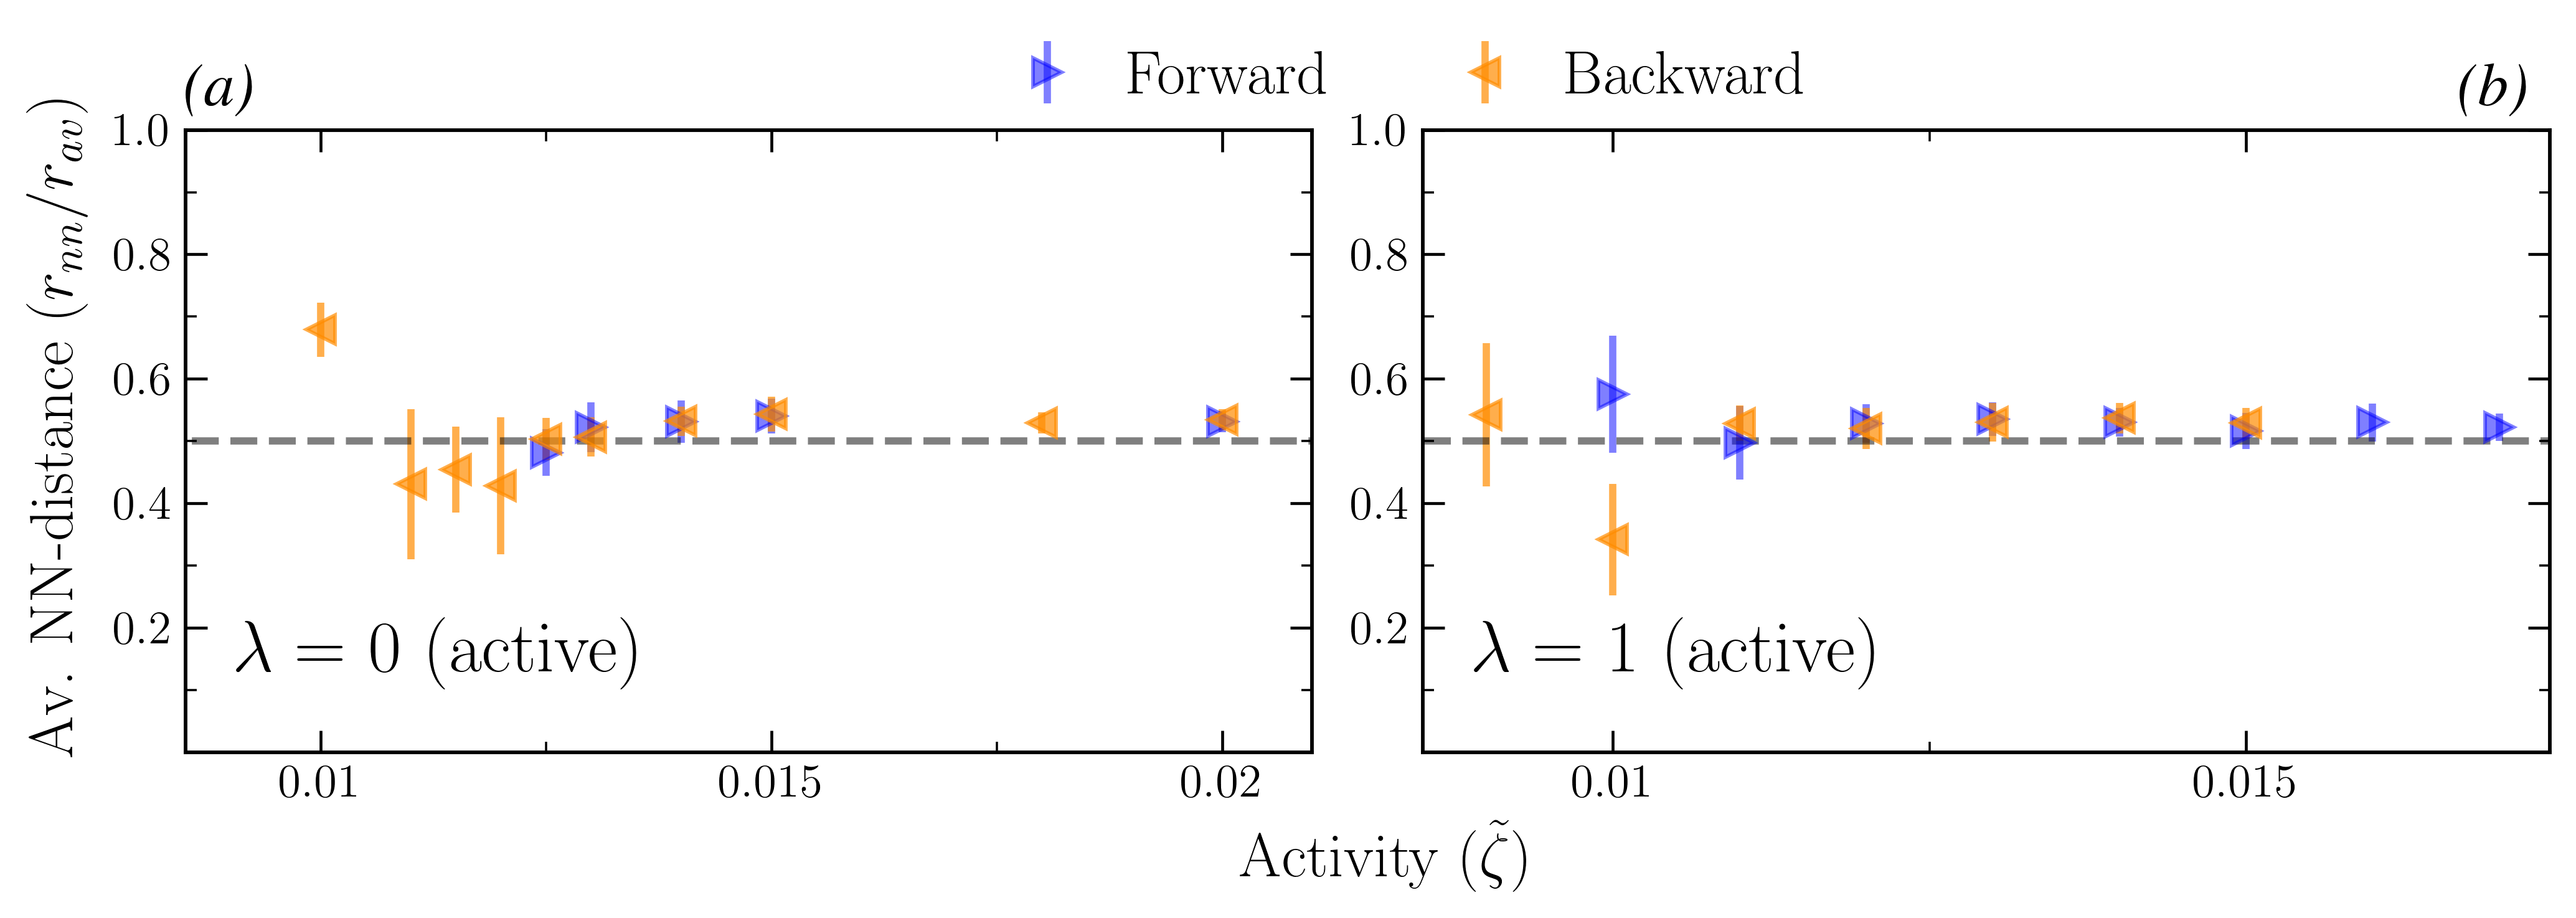

In [ ]:
### Active RNN plot ###

width=10
fig, ax0 = plt.subplots(ncols = 2, figsize=(width,width/2.8),)
act_min_idx_bck = 1
font_size = 17

if mode == 'ac':
  for i, ax in enumerate(ax0[:]):
      
      out_path_all = f'C:\\Users\\Simon Andersen\\Projects\\Projects\\Thesis\\NematicAnalysis\\data\\passive\\{folder_name}\{mode}\\na{LX}'
      lambda_val = lambda_list[i]
      out_path_main = os.path.join(out_path_all, f'{lambda_val}') 
      out_path_fwd = os.path.join(out_path_main, 'fwd')
      out_path_bck = os.path.join(out_path_main, 'bck')

    
      act_bck = np.load(os.path.join(out_path_bck, 'act_bck.npy'))
      act_fwd = np.load(os.path.join(out_path_fwd, 'act_fwd.npy'))
      act_bck = act_bck[act_min_idx_bck:]

      nn_arr_fwd_av = np.load(os.path.join(out_path_fwd, 'nn_av.npy'))
      nn_arr_bck_av = np.load(os.path.join(out_path_bck, 'nn_av.npy'))[act_min_idx_bck:]

      
      xticks=[0.0, 0.005, 0.01, 0.015, 0.02]
      yticks=[0.2, 0.4, 0.6, 0.8, 1.0]
      xtick_labels=[r'~~0.0', '0.005', '0.01', '0.015', '0.02']

      ax.set_xticks(xticks, xticks)
      ax.set_yticks(yticks, yticks)
      ax.tick_params(axis='both',which='major', labelsize=13)
      ax.set_ylim((0,1))#0.8))
      
      ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))
      ax.xaxis.set_minor_locator(ticker.MultipleLocator(2.5e-3))

      act_fwd_mask = (act_fwd > 0.0085)
      act_bck_mask = (act_bck > 0.0085)
      if i==1:
        act_fwd_mask = act_fwd_mask & (act_fwd < 0.0175)
        act_bck_mask = act_bck_mask & (act_bck < 0.0175)


      ax.errorbar(act_fwd[act_fwd_mask], nn_arr_fwd_av[act_fwd_mask,0], yerr=nn_arr_fwd_av[act_fwd_mask,1], fmt='b>', alpha=.5, ms=8, label=rf'Forward' if i==0 else None,lw=1, elinewidth=2)#$\lambda = $ {lambda_val}')# label=r'$\overline{l_{max}}$')
      ax.errorbar(act_bck[act_bck_mask], nn_arr_bck_av[act_bck_mask,0], yerr=nn_arr_bck_av[act_bck_mask,1], fmt='<', color='darkorange', alpha=.7, ms=8, label=rf'Backward' if i==0 else None,lw=1, elinewidth=2)# label=r'$\overline{l_{max}}$')
      
      
      ax.set_xlim((.0085, min(ax.get_xlim()[1], 0.021)))
      ax.hlines(0.5, -1, max(act_fwd[-1], act_bck[-1])*2, linestyle='--', color='black', alpha=0.5,)
      ax.text(0.045, 0.13, rf'$\lambda = ~${lambda_val} (active)', transform=ax.transAxes, fontsize=20)


      # load csv and print
     # df_nn_loaded = pd.read_csv(os.path.join(data_save_path, f'fig{fig_letter}.csv'), index_col=0)

  if letter_subfigs:
    for n, AXX in enumerate(ax0):
      AXX.text(0 if n==0 else .92, 1.04, rf"{{\fontfamily{{ntxtlf}}\selectfont\textit{{({string.ascii_lowercase[n]})}}}}", transform=AXX.transAxes,
              size=font_size,  weight='normal',)#fontstyle='italic',fontfamily="Times New Roman",)
      

  fig.supylabel(r'Av. NN-distance ($r_{nn}/r_{av}$)', fontsize=font_size, y=.57)
  fig.supxlabel((r'Activity ($\tilde\zeta$)'), fontsize=font_size, y=0.07, x=.54)
  fig.legend(fontsize=font_size,loc='upper center', bbox_to_anchor=(0.55, 1.03), ncol=2)

  fig.tight_layout() 
  save_path = os.path.join(out_path_all, 'figs')
  if not os.path.isdir(save_path):
      os.makedirs(save_path)

  if save_figs:
    fig.savefig(os.path.join(save_path, f'rnn_{mode}_v3.pdf'), dpi=620, bbox_inches='tight', pad_inches=.05) 
    fig.savefig(os.path.join(figpath_article, f'rnn_{mode}_v3.pdf'), dpi=620, bbox_inches='tight', pad_inches=.05) 
    print('Figure saved to ', os.path.join(save_path, f'rnn_{mode}_v3.pdf'))

In [32]:
data_save_path = os.path.join(os.environ['Research'], 'Defect Unbinding', 'Data', 'ac')
os.makedirs(data_save_path, exist_ok=True)

act_tot = np.unique(np.concatenate([act_bck[act_bck_mask], act_fwd[act_fwd_mask]]))
act_tot, act_bck[act_bck_mask]

# find indices of act_tot in act_bck and act_fwd
#act_bck_idx = np.where(act_bck[:, None] == act_tot[None, :])[0][:,0]
#act_fwd_idx = [np.argmin(np.abs(act_fwd - a)) for a in act_tot]
act_bck_extended_mask = np.isin(act_tot, act_bck)
act_fwd_extended_mask = np.isin(act_tot, act_fwd)

# make a pandas dataframe with act_tot as index, and columns for nn distance and uncertainty for fwd and bck

df_nn = pd.DataFrame(index=act_tot, columns=['nn_fwd_av', 'nn_fwd_sem', 'nn_bck_av', 'nn_bck_sem'])
# name the index column at 'Activity'
df_nn.index.name = 'activity'
df_nn.loc[act_fwd[act_fwd_mask], 'nn_fwd_av'] = nn_arr_fwd_av[act_fwd_mask,0]
df_nn.loc[act_fwd[act_fwd_mask], 'nn_fwd_sem'] = nn_arr_fwd_av[act_fwd_mask,1]
df_nn.loc[act_bck[act_bck_mask], 'nn_bck_av'] = nn_arr_bck_av[act_bck_mask,0]
df_nn.loc[act_bck[act_bck_mask], 'nn_bck_sem'] = nn_arr_bck_av[act_bck_mask,1]
df_nn = df_nn.astype(float)
df_nn['nn_fwd_sem']

# save to csv
fig_letter = f'4{string.ascii_lowercase[i]}'
df_nn.to_csv(os.path.join(data_save_path, f'fig{fig_letter}.csv'), index=True)
print('Data saved to ', os.path.join(data_save_path, f'fig{fig_letter}.csv'))

# load csv and print
df_nn_loaded = pd.read_csv(os.path.join(data_save_path, f'fig{fig_letter}.csv'), index_col=0)

Data saved to  C:\Users\Simon Andersen\OneDrive-KU\PhD\Research\Defect Unbinding\Data\ac\fig4b.csv


In [26]:
nn_arr_fwd_av[act_fwd_mask,1]

array([       nan, 0.09392845, 0.05911702, 0.03125578, 0.02728558,
       0.02299642, 0.02894918, 0.03031384, 0.0219712 ])

#### Plot dry superfigure

[0.14 0.15 0.16 0.17 0.18 0.2  0.22 0.25 0.3  0.35 0.4 ] [0.14 0.15 0.16 0.17 0.18 0.2  0.22 0.25]


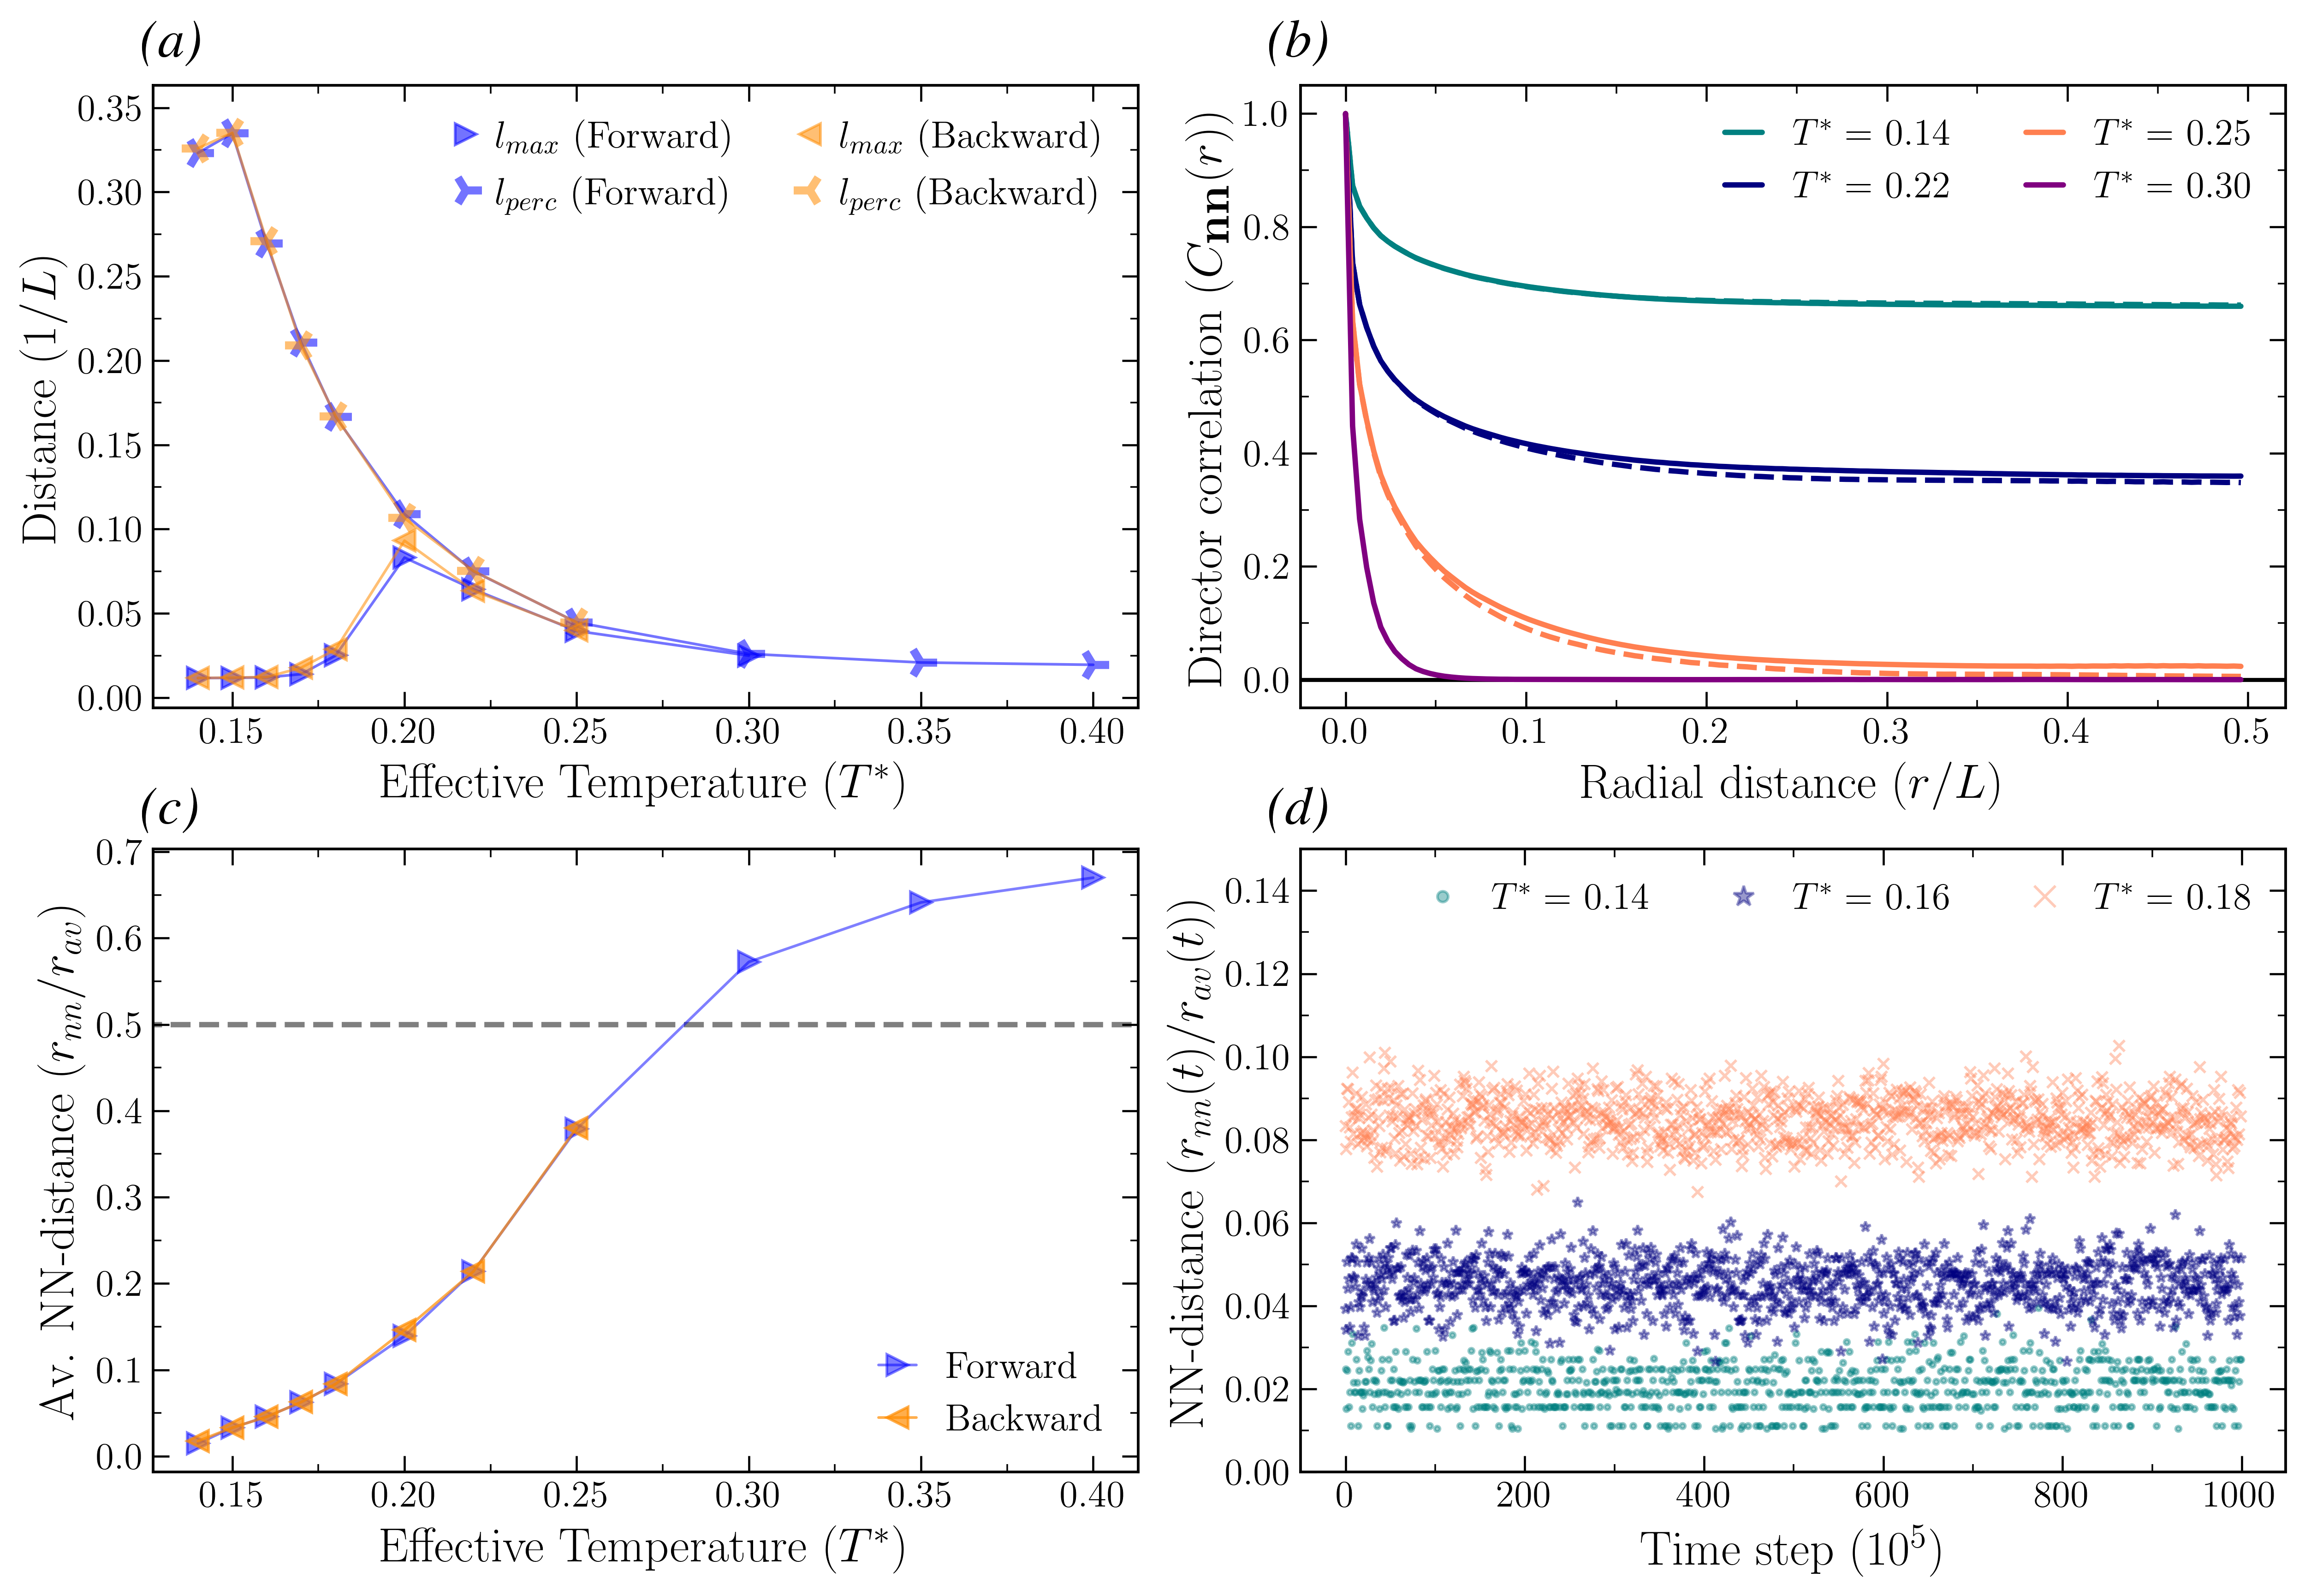

In [38]:

plt.rcParams.update({"text.usetex": True, "legend.fontsize": 14, "legend.handlelength": 0})
marker_list = ['dotted', 'dashed', 'dashdot']
plot_lmperc_bck = True
normalize=True
normalize_rnnvt = True
act_fwd_idx_min = 2
act_bck_idx_min = 7

if mode == 'dryvl':

    fig, ax = plt.subplots(ncols=2,nrows=2, figsize=(12, 8))
    ax = ax.flatten()

    out_path_fwd = 'C:\\Users\\Simon Andersen\\Projects\\Projects\\Thesis\\NematicAnalysis\\data\\passive\\dry_periodic_long\\dry\\na256\\1\\fwd'
    out_path_fwd_vl = 'C:\\Users\\Simon Andersen\\Projects\\Projects\\Thesis\\NematicAnalysis\\data\\passive\\dry_periodic_vl\\dryvl\\na256\\1\\fwd'
 
    nmin_samples=5
    normalizer = LX if normalize else 1

    act_fwd_vl = np.load(os.path.join(out_path_fwd_vl, 'act_fwd.npy'))
    rdf_arr_av_fwd_vl = np.load(os.path.join(out_path_fwd_vl, 'rdf_arr_av.npy'))

    act_bck = np.load(os.path.join(out_path_bck, 'act_bck.npy'))
    act_fwd = np.load(os.path.join(out_path_fwd, 'act_fwd.npy'))
    conv_list_fwd = np.load(os.path.join(out_path_fwd, 'conv_list.npy'))
    conv_list_bck = np.load(os.path.join(out_path_bck, 'conv_list.npy'))
    def_arr_fwd = np.load(os.path.join(out_path_fwd, 'def_arr.npy'))
    def_arr_bck = np.load(os.path.join(out_path_bck, 'def_arr.npy'))
    lmax_av_fwd = np.load(os.path.join(out_path_fwd, 'lmax_av.npy')) / normalizer
    lperc_av_fwd = np.load(os.path.join(out_path_fwd, 'lperc_av.npy')) / normalizer
    lmax_av_bck = np.load(os.path.join(out_path_bck, 'lmax_av.npy')) / normalizer
    lperc_av_bck = np.load(os.path.join(out_path_bck, 'lperc_av.npy')) / normalizer
    
    rvals = np.load(os.path.join(out_path_fwd, 'rvals.npy'))
    rdf_arr_av_bck = np.load(os.path.join(out_path_bck, 'rdf_arr_av.npy'))
    rdf_arr_av_fwd = np.load(os.path.join(out_path_fwd, 'rdf_arr_av.npy'))

    nn_arr_fwd = np.load(os.path.join(out_path_fwd, 'nn_arr.npy'))
    nn_arr_bck = np.load(os.path.join(out_path_bck, 'nn_arr.npy'))
    nn_arr_fwd_av = np.load(os.path.join(out_path_fwd, 'nn_av.npy'))
    nn_arr_bck_av = np.load(os.path.join(out_path_bck, 'nn_av.npy'))
    nn_arr_fwd_weighted_av = np.nan * np.zeros((len(act_fwd),2))

    
    ax[2].errorbar(act_fwd[act_fwd_idx_min:], nn_arr_fwd_av[act_fwd_idx_min:,0], yerr=nn_arr_fwd_av[act_fwd_idx_min:,1], alpha=.5,ms=8,fmt='b>-', label=r'Forward', lw=1, elinewidth=2,ecolor='white')# if i==0 else None)#$\overline{l_{max}}$ (Forward)' if i==0 else None)# label=r'$\overline{l_{max}}$')
    ax[2].errorbar(act_bck[act_bck_idx_min:], nn_arr_bck_av[act_bck_idx_min:,0], yerr=nn_arr_bck_av[act_bck_idx_min:,1], fmt='<-',color='darkorange', alpha=.7, ms=8,lw=1, elinewidth=2, label=r'Backward',ecolor='white')#  if i==0 else None) # $~~~~~~~~~\hspace{5em}$' if i==0 else None)# label=r'$\overline{l_{perc}}$')
  
    # ------------------------------------
    if not plot_lmperc_bck:
        ax[0].errorbar(act_fwd[act_fwd_idx_min:], lmax_av_fwd[act_fwd_idx_min:,0], yerr=lmax_av_fwd[act_fwd_idx_min:,1], alpha=.6,ms=8,fmt='d-', label=r'$l_{max}$ (Forward)', lw=1, elinewidth=2, )#if i==0 else None)# label=r'$\overline{l_{max}}$')
        ax[0].errorbar(act_fwd[act_fwd_idx_min:], lperc_av_fwd[act_fwd_idx_min:,0], yerr=lperc_av_fwd[act_fwd_idx_min:,1], alpha=.6,ms=8, fmt='*-',color=f'C{3}', lw=1, elinewidth=2, label=r'$l_{perc}$ (Forward) $~~~~~~~~~\hspace{5em}$')# if i==0 else None)# label=r'$\overline{l_{perc}}$')

    if plot_lmperc_bck:
        ax[0].errorbar(act_fwd[act_fwd_idx_min:], lmax_av_fwd[act_fwd_idx_min:,0], yerr=lmax_av_fwd[act_fwd_idx_min:,1], alpha=.55,ms=8,fmt='>-',color='blue',ecolor='white', lw=1, label=r'$l_{max}$ (Forward)')# label=r'$\overline{l_{max}}$')
        ax[0].errorbar(act_fwd[act_fwd_idx_min:], lperc_av_fwd[act_fwd_idx_min:,0], yerr=lperc_av_fwd[act_fwd_idx_min:,1], alpha=.55,ms=12, fmt='4-',color='blue', mew=3,ecolor='white', lw=1, label=r'$l_{perc}$ (Forward)')# label=r'$\overline{l_{perc}}$')
    
        ax[0].errorbar(act_bck[act_bck_idx_min:], lmax_av_bck[act_bck_idx_min:,0], yerr=lmax_av_bck[act_bck_idx_min:,1], alpha=.55, ms=8,fmt='<-',color='darkorange',lw=1, label=r'$l_{max}$ (Backward)', ecolor='white')# label=r'$\overline{l_{max}}$')
        ax[0].errorbar(act_bck[act_bck_idx_min:], lperc_av_bck[act_bck_idx_min:,0], yerr=lperc_av_bck[act_bck_idx_min:,1], ms=12,alpha=.55,fmt='3-', mew=3, ecolor='white', color='darkorange',lw=1, label=r'$l_{perc}$ (Backward)')# label=r'$\overline{l_{perc}}$')

        print(act_fwd[act_fwd_idx_min:], act_bck[act_bck_idx_min:])

    # ------------------------------------
    act_include_list = [.14, .22, .25, .30]

    for j, act in enumerate(act_include_list):
        try:
            if act in act_fwd_vl:
                act_idx_fwd_vl = np.argwhere(act_fwd_vl == act)[0][0]
                ax[1].plot(rvals/LX, rdf_arr_av_fwd_vl[act_idx_fwd_vl, 0,:],'-', color=f'C{j}', label = rf'$T^*=~${act:.2f}')
            else:
                act_idx_fwd = np.argwhere(act_fwd == act)[0][0]
                ax[1].plot(rvals/LX, rdf_arr_av_fwd[act_idx_fwd, 0,:],'-', color=f'C{j}',  label = rf'$T^*=~${act:.2f}')
        except:
            pass
        try:
            act_idx_bck = np.argwhere(act_bck == act)[0][0]
            ax[1].plot(rvals/LX, rdf_arr_av_bck[act_idx_bck, 0,:],ls='dashed', color=f'C{j}',)# label = rf'$T^* = ${act:.3f}' if j==0 else None) # $~~~~~~~~~\hspace{5em}$' if i==0 else None)# label=r'$\overline{l_{perc}}$')
        except:
            pass

    act_include_list = act_bck[act_bck_idx_min:act_bck_idx_min+3]
    act_include_list=[.14,.16,.18,]
    marker_list=['.','*','x']

    for j, T in enumerate(act_include_list):
        try: 
            act_idx = np.argwhere(act_bck == T)[0][0]
            mask_bck = nn_arr_bck[:,0, act_idx ] > 0
            normalizer = LX / np.sqrt(def_arr_bck[mask_bck, act_idx]) if normalize_rnnvt else 1#LX
            if mask_bck.sum() < nmin_samples: 
                print(f'Not enough samples for {T}')
                continue
            ax[3].plot(np.arange(Nframes)[mask_bck], nn_arr_bck[mask_bck, 0, act_idx] / normalizer, marker=marker_list[j%3],lw=0,ms=4,alpha=.4, #ls=marker_list[j%3],
                        label = rf'$T^*=~${T:.2f}')    
        except:
            act_idx = np.argwhere(act_fwd == T)[0][0]
            mask_fwd = nn_arr_fwd[:,0, act_idx ] > 0
            normalizer = LX / np.sqrt(def_arr_fwd[mask_fwd, act_idx]) if normalize_rnnvt else 1#LX
            ax[3].plot(np.arange(Nframes)[mask_fwd], nn_arr_fwd[mask_fwd, 0, act_idx] / normalizer,  marker=marker_list[j%3], lw=0, # ls=marker_list[j%3],
                        label = rf'$T^*=~${T:.2f}')
            

    for a in ax:
        a.tick_params(axis='both',which='major', labelsize=14)
        a.set_xlim(a.get_xlim())
        a.set_ylim(a.get_ylim())


    ax[0].xaxis.set_minor_locator(ticker.MultipleLocator(0.025))
    ax[0].yaxis.set_minor_locator(ticker.MultipleLocator(0.025 if normalize else 10))
    ax[0].set_xlabel(r'Effective Temperature ($T^*$)')
    ax[0].set_ylabel(r'Distance ($1/L$)')
    ax[0].legend(ncols=2)

    ax[1].xaxis.set_minor_locator(ticker.MultipleLocator(0.05))
    ax[1].yaxis.set_minor_locator(ticker.MultipleLocator(0.1))
    ax[1].legend(loc='upper right', handlelength=1, ncol=2)
    ax[1].hlines(0, *ax[1].get_xlim(), linestyle='-', lw=1.5, color='black', alpha=1,zorder=-1)
    ax[1].set_xlabel((r'Radial distance ($r/L$)'))
    ax[1].set_ylabel(r'Director correlation ($C_{\textbf{nn}} (r)$)')

    ax[2].xaxis.set_minor_locator(ticker.MultipleLocator(0.025))
    ax[2].yaxis.set_minor_locator(ticker.MultipleLocator(0.05))
    ax[2].hlines(0.5, -.1, max(act_fwd[-1], act_bck[-1])+.1, linestyle='--', color='black', alpha=0.5,)
    ax[2].set_ylabel(r'Av. NN-distance ($r_{nn}/r_{av}$)')
    ax[2].set_xlabel((r'Effective Temperature ($T^*$)'))
    ax[2].legend(loc='lower right', handlelength=1)

    ax[3].xaxis.set_minor_locator(ticker.MultipleLocator(100))
    ax[3].yaxis.set_minor_locator(ticker.MultipleLocator(0.01 if normalize else 10))
    ax[3].set_ylabel(r'NN-distance ($r_{nn}(t)/r_{av}(t)$)' if normalize_rnnvt else r'NN-distance ($r_{nn}(t)/L$)')
    ax[3].set_xlabel((r'Time step ($10^5$)'))          
    ax[3].legend(handlelength=1, ncols=3, loc='upper right', markerscale=2)
    ax[3].set_ylim([0,.15])


    if letter_subfigs:
        for n, AXX in enumerate(ax):
            fig.text(0.065 if n%2==0 else 0.55, 1.0 if n<2 else 0.505, rf"{{\fontfamily{{ntxtlf}}\selectfont\textit{{({string.ascii_lowercase[n]})}}}}",# transform=AXX.transAxes,
                    size=20,  weight='bold',fontstyle='italic', fontfamily="Times New Roman",)
    else:  
        for n, AXX in enumerate(ax):
            fig.text(0.065 if n%2==0 else 0.55, 1.0 if n<2 else 0.505, rf'$\it{{({string.ascii_lowercase[n]})}}$',# transform=AXX.transAxes,
                    size=20,  weight='bold',fontstyle='italic', fontfamily="Times New Roman", color= 'white')
    
    save_path = os.path.join(out_path_all, 'figs')
    fig.tight_layout()
    if not os.path.isdir(save_path):
        os.makedirs(save_path)
    if save_figs:
        fig.savefig(os.path.join(save_path, f'dry_vl2{"_unlabeled" if not letter_subfigs else ""}.pdf'), bbox_inches='tight', pad_inches=.1, dpi=620)
        fig.savefig(os.path.join(figpath_article, f'dry_vl2{"_unlabeled" if not letter_subfigs else ""}.pdf'), bbox_inches='tight', pad_inches=.1, dpi=620)

In [81]:
act_include_list=[.14,.16,.18,]
marker_list=['.','*','x']

data_mode='dry'
index_name='time_step'
i=3
fig_num = 5

fig_letter = f'{fig_num}{string.ascii_lowercase[i]}'
#fig_letter= f'{fig_num}a+c'
data_save_path = os.path.join(os.environ['Research'], 'Defect Unbinding', 'Data', data_mode)
os.makedirs(data_save_path, exist_ok=True)

xvals=np.arange(Nframes)

df_nn = pd.DataFrame(index=xvals, columns=['rnn_av_normalized(T=0.14)', 'rnn_av_normalized(T=0.16)', 'rnn_av_normalized(T=0.18)',]  )
# name the index column at 'Activity'
df_nn.index.name = index_name

for j, T in enumerate(act_include_list):
    try: 
        act_idx = np.argwhere(act_bck == T)[0][0]
        mask_bck = nn_arr_bck[:,0, act_idx ] > 0
        normalizer = LX / np.sqrt(def_arr_bck[mask_bck, act_idx]) if normalize_rnnvt else 1#LX
        df_nn.loc[xvals[mask_bck], f'rnn_av_normalized(T={T})'] = nn_arr_bck[mask_bck, 0, act_idx] / normalizer
        

    except:
        act_idx = np.argwhere(act_fwd == T)[0][0]
        mask_fwd = nn_arr_fwd[:,0, act_idx ] > 0
        normalizer = LX / np.sqrt(def_arr_fwd[mask_fwd, act_idx]) if normalize_rnnvt else 1#LX
        df_nn.loc[xvals[mask_fwd], f'rnn_av_normalized(T={T})'] = nn_arr_fwd[mask_fwd, 0, act_idx] / normalizer

df_nn = df_nn.astype(float)
df_nn.head()
df_nn.to_csv(os.path.join(data_save_path, f'fig{fig_letter}.csv'), index=True)
print('Data saved to ', os.path.join(data_save_path, f'fig{fig_letter}.csv'))

Data saved to  C:\Users\Simon Andersen\OneDrive-KU\PhD\Research\Defect Unbinding\Data\dry\fig5d.csv


In [75]:
act_include_list = [.14, .22, .25, .30]


data_mode='dry'
index_name='radial_distance_normalized'
i=1
fig_num = 5

fig_letter = f'{fig_num}{string.ascii_lowercase[i]}'
#fig_letter= f'{fig_num}a+c'
data_save_path = os.path.join(os.environ['Research'], 'Defect Unbinding', 'Data', data_mode)
os.makedirs(data_save_path, exist_ok=True)

xvals=rvals/LX

# make npz file with all data
#dirr_corr_data = {}
#radial_distance_normalized = rvals/LX



df_nn = pd.DataFrame(index=xvals, columns=['dir_corr_fwd_(T=0.14)', 'dir_corr_bck_(T=0.14)', 
                                           'dir_corr_fwd_(T=0.22)', 'dir_corr_bck_(T=0.22)'
                                          'dir_corr_fwd_(T=0.25)', 'dir_corr_bck_(T=0.25)',
                                          'dir_corr_fwd_(T=0.3)', 'dir_corr_bck_(T=0.3)']  )
# name the index column at 'Activity'
df_nn.index.name = index_name

act_include_list = [.14, .22, .25, .30]

rdf_fwd_list = []
rdf_bck_list = []

for j, act in enumerate(act_include_list):
    try:
        if act in act_fwd_vl:
            act_idx_fwd_vl = np.argwhere(act_fwd_vl == act)[0][0]
            rdf_fwd_list.append(rdf_arr_av_fwd_vl[act_idx_fwd_vl, 0,:])
           # ax[1].plot(rvals/LX, rdf_arr_av_fwd_vl[act_idx_fwd_vl, 0,:],'-', color=f'C{j}', label = rf'$T^*=~${act:.2f}')
        else:
            act_idx_fwd = np.argwhere(act_fwd == act)[0][0]
            rdf_fwd_list.append(rdf_arr_av_fwd[act_idx_fwd, 0,:])
           # ax[1].plot(rvals/LX, rdf_arr_av_fwd[act_idx_fwd, 0,:],'-', color=f'C{j}',  label = rf'$T^*=~${act:.2f}')
    except:
        pass
    try:
        act_idx_bck = np.argwhere(act_bck == act)[0][0]
        rdf_bck_list.append(rdf_arr_av_bck[act_idx_bck, 0,:])
        #ax[1].plot(rvals/LX, rdf_arr_av_bck[act_idx_bck, 0,:],ls='dashed', color=f'C{j}',)# label = rf'$T^* = ${act:.3f}' if j==0 else None) # $~~~~~~~~~\hspace{5em}$' if i==0 else None)# label=r'$\overline{l_{perc}}$')
    except:
        pass

for j, T in enumerate(act_include_list):
    df_nn.loc[:, f'dir_corr_fwd_(T={T})'] = rdf_fwd_list[j]
    if j < len(rdf_bck_list):
        df_nn.loc[:, f'dir_corr_bck_(T={T})'] = rdf_bck_list[j]

# remove columns with all NaN values
df_nn = df_nn.dropna(axis=1, how='all')
# convert to float
df_nn = df_nn.astype(float)
# save to csv
df_nn.to_csv(os.path.join(data_save_path, f'fig{fig_letter}.csv'), index=True)
print('Data saved to ', os.path.join(data_save_path, f'fig{fig_letter}.csv'))


Data saved to  C:\Users\Simon Andersen\OneDrive-KU\PhD\Research\Defect Unbinding\Data\dry\fig5b.csv


C:\Users\Simon Andersen\AppData\Local\Temp\ipykernel_10184\866150319.py:56: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  df_nn.loc[:, f'dir_corr_bck_(T={T})'] = rdf_bck_list[j]
C:\Users\Simon Andersen\AppData\Local\Temp\ipykernel_10184\866150319.py:54: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  df_nn.loc[:, f'dir_corr_fwd_(T={T})'] = rdf_fwd_list[j]


In [ ]:

data_mode='dry'
index_name='effective_temperature'
i=1
fig_num = 5

fig_letter = f'{fig_num}{string.ascii_lowercase[i]}'
#fig_letter= f'{fig_num}a+c'
data_save_path = os.path.join(os.environ['Research'], 'Defect Unbinding', 'Data', data_mode)
os.makedirs(data_save_path, exist_ok=True)



#act_tot = np.unique(np.concatenate([act_bck[act_bck_mask], act_fwd[act_fwd_mask]]))

act_tot = np.unique(np.concatenate([act_fwd[act_fwd_idx_min:], act_bck[act_bck_idx_min:]]))
#act_fwd[act_fwd_idx_min:], act_bck[act_bck_idx_min:]
# find indices of act_tot in act_bck and act_fwd
#act_bck_idx = np.where(act_bck[:, None] == act_tot[None, :])[0][:,0]
#act_fwd_idx = [np.argmin(np.abs(act_fwd - a)) for a in act_tot]
act_bck_extended_mask = np.isin(act_tot, act_bck)
act_fwd_extended_mask = np.isin(act_tot, act_fwd)

# make a pandas dataframe with act_tot as index, and columns for nn distance and uncertainty for fwd and bck

df_nn = pd.DataFrame(index=act_tot, columns=['lmax_fwd_av', 'lmax_fwd_sem', 'lmax_bck_av', 'lmax_bck_sem',
                                            'lperc_fwd_av', 'lperc_fwd_sem', 'lperc_bck_av', 'lperc_bck_sem',
                                            'nn_arr_fwd_av', 'nn_arr_fwd_sem', 'nn_arr_bck_av', 'nn_arr_bck_sem']  )
# name the index column at 'Activity'
df_nn.index.name = index_name
df_nn.loc[act_fwd[act_fwd_idx_min:], 'lmax_fwd_av'] = lmax_av_fwd[act_fwd_idx_min:,0]
df_nn.loc[act_fwd[act_fwd_idx_min:], 'lmax_fwd_sem'] = lmax_av_fwd[act_fwd_idx_min:,1]
df_nn.loc[act_bck[act_bck_idx_min:], 'lmax_bck_av'] = lmax_av_bck[act_bck_idx_min:,0]
df_nn.loc[act_bck[act_bck_idx_min:], 'lmax_bck_sem'] = lmax_av_bck[act_bck_idx_min:,1]
df_nn.loc[act_fwd[act_fwd_idx_min:], 'lperc_fwd_av'] = lperc_av_fwd[act_fwd_idx_min:,0]
df_nn.loc[act_fwd[act_fwd_idx_min:], 'lperc_fwd_sem'] = lperc_av_fwd[act_fwd_idx_min:,1]
df_nn.loc[act_bck[act_bck_idx_min:], 'lperc_bck_av'] = lperc_av_bck[act_bck_idx_min:,0]
df_nn.loc[act_bck[act_bck_idx_min:], 'lperc_bck_sem'] = lperc_av_bck[act_bck_idx_min:,1]
df_nn.loc[act_fwd[act_fwd_idx_min:], 'nn_arr_fwd_av'] = nn_arr_fwd_av[act_fwd_idx_min:,0]
df_nn.loc[act_fwd[act_fwd_idx_min:], 'nn_arr_fwd_sem'] = nn_arr_fwd_av[act_fwd_idx_min:,1]
df_nn.loc[act_bck[act_bck_idx_min:], 'nn_arr_bck_av'] = nn_arr_bck_av[act_bck_idx_min:,0]
df_nn.loc[act_bck[act_bck_idx_min:], 'nn_arr_bck_sem'] = nn_arr_bck_av[act_bck_idx_min:,1]

df_nn = df_nn.astype(float)

# save to csv
#fig_letter = f'4{string.ascii_lowercase[i]}'
df_nn.to_csv(os.path.join(data_save_path, f'fig{fig_letter}.csv'), index=True)
print('Data saved to ', os.path.join(data_save_path, f'fig{fig_letter}.csv'))

# load csv and print
df_nn_loaded = pd.read_csv(os.path.join(data_save_path, f'fig{fig_letter}.csv'), index_col=0)
print(df_nn_loaded)

In [ ]:

data_mode='dry'
index_name='effective_temperature'
i=0
fig_num = 5

fig_letter = f'{fig_num}{string.ascii_lowercase[i]}'
fig_letter= f'{fig_num}a+c'
data_save_path = os.path.join(os.environ['Research'], 'Defect Unbinding', 'Data', data_mode)
os.makedirs(data_save_path, exist_ok=True)



#act_tot = np.unique(np.concatenate([act_bck[act_bck_mask], act_fwd[act_fwd_mask]]))

act_tot = np.unique(np.concatenate([act_fwd[act_fwd_idx_min:], act_bck[act_bck_idx_min:]]))
#act_fwd[act_fwd_idx_min:], act_bck[act_bck_idx_min:]
# find indices of act_tot in act_bck and act_fwd
#act_bck_idx = np.where(act_bck[:, None] == act_tot[None, :])[0][:,0]
#act_fwd_idx = [np.argmin(np.abs(act_fwd - a)) for a in act_tot]
act_bck_extended_mask = np.isin(act_tot, act_bck)
act_fwd_extended_mask = np.isin(act_tot, act_fwd)

# make a pandas dataframe with act_tot as index, and columns for nn distance and uncertainty for fwd and bck

df_nn = pd.DataFrame(index=act_tot, columns=['lmax_fwd_av', 'lmax_fwd_sem', 'lmax_bck_av', 'lmax_bck_sem',
                                            'lperc_fwd_av', 'lperc_fwd_sem', 'lperc_bck_av', 'lperc_bck_sem',
                                            'nn_arr_fwd_av', 'nn_arr_fwd_sem', 'nn_arr_bck_av', 'nn_arr_bck_sem']  )
# name the index column at 'Activity'
df_nn.index.name = index_name
df_nn.loc[act_fwd[act_fwd_idx_min:], 'lmax_fwd_av'] = lmax_av_fwd[act_fwd_idx_min:,0]
df_nn.loc[act_fwd[act_fwd_idx_min:], 'lmax_fwd_sem'] = lmax_av_fwd[act_fwd_idx_min:,1]
df_nn.loc[act_bck[act_bck_idx_min:], 'lmax_bck_av'] = lmax_av_bck[act_bck_idx_min:,0]
df_nn.loc[act_bck[act_bck_idx_min:], 'lmax_bck_sem'] = lmax_av_bck[act_bck_idx_min:,1]
df_nn.loc[act_fwd[act_fwd_idx_min:], 'lperc_fwd_av'] = lperc_av_fwd[act_fwd_idx_min:,0]
df_nn.loc[act_fwd[act_fwd_idx_min:], 'lperc_fwd_sem'] = lperc_av_fwd[act_fwd_idx_min:,1]
df_nn.loc[act_bck[act_bck_idx_min:], 'lperc_bck_av'] = lperc_av_bck[act_bck_idx_min:,0]
df_nn.loc[act_bck[act_bck_idx_min:], 'lperc_bck_sem'] = lperc_av_bck[act_bck_idx_min:,1]
df_nn.loc[act_fwd[act_fwd_idx_min:], 'nn_arr_fwd_av'] = nn_arr_fwd_av[act_fwd_idx_min:,0]
df_nn.loc[act_fwd[act_fwd_idx_min:], 'nn_arr_fwd_sem'] = nn_arr_fwd_av[act_fwd_idx_min:,1]
df_nn.loc[act_bck[act_bck_idx_min:], 'nn_arr_bck_av'] = nn_arr_bck_av[act_bck_idx_min:,0]
df_nn.loc[act_bck[act_bck_idx_min:], 'nn_arr_bck_sem'] = nn_arr_bck_av[act_bck_idx_min:,1]

df_nn = df_nn.astype(float)

# save to csv
#fig_letter = f'4{string.ascii_lowercase[i]}'
df_nn.to_csv(os.path.join(data_save_path, f'fig{fig_letter}.csv'), index=True)
print('Data saved to ', os.path.join(data_save_path, f'fig{fig_letter}.csv'))

# load csv and print
df_nn_loaded = pd.read_csv(os.path.join(data_save_path, f'fig{fig_letter}.csv'), index_col=0)
print(df_nn_loaded)

In [48]:
df_nn_loaded.head()

,lmax_fwd_av,lmax_fwd_sem,lmax_bck_av,lmax_bck_sem,lperc_fwd_av,lperc_fwd_sem,lperc_bck_av,lperc_bck_sem,nn_arr_fwd_av,nn_arr_fwd_sem,nn_arr_bck_av,nn_arr_bck_sem
effective_temperature,,,,,,,,,,,,
0.14,0.011638,0.000080,0.011654,0.000085,0.323125,0.020537,0.325915,0.020585,0.014746,1.113047e-17,0.017550,1.294705e-16
0.15,0.011743,0.000062,0.011928,0.000917,0.334800,0.008450,0.335123,0.008612,0.033039,2.915432e-05,0.033119,2.937084e-05
0.16,0.012042,0.001131,0.012262,0.001572,0.269476,0.005466,0.270881,0.005461,0.045867,2.341512e-05,0.045663,2.320129e-05
0.17,0.013973,0.002786,0.017776,0.003144,0.210613,0.003755,0.208980,0.003665,0.062563,2.627467e-05,0.062726,2.822911e-05
0.18,0.025039,0.006904,0.028621,0.007780,0.166630,0.002742,0.166986,0.002614,0.083634,3.685078e-05,0.083625,3.799149e-05


In [42]:

data_mode='dry'
index_name='effective_temperature'
i=0
fig_num = 5

fig_letter = f'{fig_num}{string.ascii_lowercase[i]}'
data_save_path = os.path.join(os.environ['Research'], 'Defect Unbinding', 'Data', data_mode)
os.makedirs(data_save_path, exist_ok=True)



#act_tot = np.unique(np.concatenate([act_bck[act_bck_mask], act_fwd[act_fwd_mask]]))

act_tot = np.unique(np.concatenate([act_fwd[act_fwd_idx_min:], act_bck[act_bck_idx_min:]]))
#act_fwd[act_fwd_idx_min:], act_bck[act_bck_idx_min:]
# find indices of act_tot in act_bck and act_fwd
#act_bck_idx = np.where(act_bck[:, None] == act_tot[None, :])[0][:,0]
#act_fwd_idx = [np.argmin(np.abs(act_fwd - a)) for a in act_tot]
act_bck_extended_mask = np.isin(act_tot, act_bck)
act_fwd_extended_mask = np.isin(act_tot, act_fwd)

# make a pandas dataframe with act_tot as index, and columns for nn distance and uncertainty for fwd and bck

df_nn = pd.DataFrame(index=act_tot, columns=['lmax_fwd_av', 'lmax_fwd_sem', 'lmax_bck_av', 'lmax_bck_sem',
                                            'lperc_fwd_av', 'lperc_fwd_sem', 'lperc_bck_av', 'lperc_bck_sem',]  )
# name the index column at 'Activity'
df_nn.index.name = index_name
df_nn.loc[act_fwd[act_fwd_idx_min:], 'lmax_fwd_av'] = lmax_av_fwd[act_fwd_idx_min:,0]
df_nn.loc[act_fwd[act_fwd_idx_min:], 'lmax_fwd_sem'] = lmax_av_fwd[act_fwd_idx_min:,1]
df_nn.loc[act_bck[act_bck_idx_min:], 'lmax_bck_av'] = lmax_av_bck[act_bck_idx_min:,0]
df_nn.loc[act_bck[act_bck_idx_min:], 'lmax_bck_sem'] = lmax_av_bck[act_bck_idx_min:,1]
df_nn.loc[act_fwd[act_fwd_idx_min:], 'lperc_fwd_av'] = lperc_av_fwd[act_fwd_idx_min:,0]
df_nn.loc[act_fwd[act_fwd_idx_min:], 'lperc_fwd_sem'] = lperc_av_fwd[act_fwd_idx_min:,1]
df_nn.loc[act_bck[act_bck_idx_min:], 'lperc_bck_av'] = lperc_av_bck[act_bck_idx_min:,0]
df_nn.loc[act_bck[act_bck_idx_min:], 'lperc_bck_sem'] = lperc_av_bck[act_bck_idx_min:,1]
df_nn = df_nn.astype(float)

# save to csv
fig_letter = f'4{string.ascii_lowercase[i]}'
df_nn.to_csv(os.path.join(data_save_path, f'fig{fig_letter}.csv'), index=True)
print('Data saved to ', os.path.join(data_save_path, f'fig{fig_letter}.csv'))

# load csv and print
df_nn_loaded = pd.read_csv(os.path.join(data_save_path, f'fig{fig_letter}.csv'), index_col=0)
print(df_nn_loaded)

Data saved to  C:\Users\Simon Andersen\OneDrive-KU\PhD\Research\Defect Unbinding\Data\dry\fig4a.csv
                       lmax_fwd_av  lmax_fwd_sem  lmax_bck_av  lmax_bck_sem  \
effective_temperature                                                         
0.14                      0.011638      0.000080     0.011654      0.000085   
0.15                      0.011743      0.000062     0.011928      0.000917   
0.16                      0.012042      0.001131     0.012262      0.001572   
0.17                      0.013973      0.002786     0.017776      0.003144   
0.18                      0.025039      0.006904     0.028621      0.007780   
0.20                      0.083105      0.006805     0.093144      0.002826   
0.22                      0.064323      0.002791     0.063457      0.002142   
0.25                      0.039601      0.003327     0.039988      0.002905   
0.30                      0.024957      0.002502          NaN           NaN   
0.35                           

In [41]:
df_nn

,lmax_fwd_av,lmax_fwd_sem,lmax_bck_av,lmax_bck_sem,lperc_fwd_av,lperc_fwd_sem,lperc_bck_av,lperc_bck_sem
effective_temperature,,,,,,,,
0.14,0.011638,0.000080,0.011654,0.000085,0.323125,0.020537,0.325915,0.020585
0.15,0.011743,0.000062,0.011928,0.000917,0.334800,0.008450,0.335123,0.008612
0.16,0.012042,0.001131,0.012262,0.001572,0.269476,0.005466,0.270881,0.005461
0.17,0.013973,0.002786,0.017776,0.003144,0.210613,0.003755,0.208980,0.003665
0.18,0.025039,0.006904,0.028621,0.007780,0.166630,0.002742,0.166986,0.002614
0.20,0.083105,0.006805,0.093144,0.002826,0.108948,0.001497,0.106554,0.001434
0.22,0.064323,0.002791,0.063457,0.002142,0.075049,0.000938,0.075241,0.000958
0.25,0.039601,0.003327,0.039988,0.002905,0.044711,0.000546,0.044614,0.000542
0.30,0.024957,0.002502,NaN,NaN,0.025989,0.000325,NaN,NaN
